EDA on Gift Card Review Dataset

In [0]:
review_df = spark.read.json("/Volumes/workspace/default/major-project-dbda/gift_cards_reviews_2015_onwards.jsonl")
print(review_df)


DataFrame[asin: string, helpful_vote: bigint, parent_asin: string, rating: bigint, text: string, timestamp: bigint, title: string, user_id: string, verified_purchase: boolean, year: bigint]


In [0]:
display(review_df)

asin,helpful_vote,parent_asin,rating,text,timestamp,title,user_id,verified_purchase,year
B00IX1I3G6,0,B00IX1I3G6,5,Having Amazon money is always good.,1549866158332,Great gift,AHZ6XMOLEWA67S3TX7IWEXXGWSOA,true,2019
B005ESMMWW,0,B005ESMMWW,5,Always the perfect gift. I have never given one and had someone seem or act disappointed. Just the opposite. They are thrilled and excited to have a bit of a spree. Always the perfect size and color! Arrives in 1 day in most cases. So it's never too late! Lots of cards to chose from... thank you... birthday... wedding..baby.. and many that work for many occasions...,1599875158120,amazon gift card,AFZUK3MTBIBEDQOPAK3OATUOUKLA,false,2020
B01K8RIM5Y,27,B005S28ZES,5,When you have a person who is hard to shop for.. an amazon gift card is P E R F E C T. Man or woman... No matter what their hobby... lifestyle.. or age. All you have to do is pick the $. Don't forget to mention that it is a GIFT when you check out - you will have some gift card options. I've ordered many of these over years. They are always received with glee. Woo hoo! If you're looking for a great fit for me - this is just my size! :) Best to all!,1535939929239,perfect gift,AFZUK3MTBIBEDQOPAK3OATUOUKLA,true,2018
B00FTGTM5E,2,B00FTGTIOE,1,"I bought this pack of Starbucks Gift cards in 2019. Ive given them to friends and I gave 2 to my daughter.My daughter used one recently and it had $6.52 on the card not $10.00. She had the cashier check the balance of the other card and it had $5.32 on it! She had forgotten that she had these gift cards, so yes, 2 years later decided to use the when she found them! Do they decline in value? And then both had random amounts on them! I'm embarrassed now to have given them as gifts! Friends receiving the gift card aren't going to tell you that weren't able to cover their order with the card you gave them!!!",1638068808115,Not $10 Gift Cards,AH5L7ILVA6HYLZOUZIQAWNHVVK3A,true,2021
B072L7GTF5,0,B00ADR2LV6,5,That snowman tin is adorable,1608661063303,Cute!,AECABX3OO3GK7FCPZLFM3LT2E6UA,true,2020
B00IX1I3G6,0,B00IX1I3G6,5,Great and easy gift,1602104097716,Easy gift,AFSCQMP2EPYLGJN7OBTMEXCBE2OQ,true,2020
B072P5VV4D,0,B00ADR2LV6,5,Super cute nice quality tinYour choose amount,1551247682370,Great gift,AF4XAUOI5XPGWHCPOTORKBIJSRDA,true,2019
B072P5VV4D,0,B00ADR2LV6,5,They love it !!,1675387900672,Gifts for my two granddaughters,AGJXTLEOLLTIX5AAGFPBZ7CNNVOQ,true,2023
B071NM2PNL,0,B071X4ZX3X,5,So many peopleMake your life better so remember them!,1674305242048,"Great for saying “thank you” to the mail person, farrier, yard man,etc",AG7QDTQYHFOIXFWSVUUBZOEIW2NA,true,2023
B01GKWEH64,2,B01GKWEEQM,5,"My grandson inlaw loves his gift cards, so it's the perfect gift for Christmas",1573997914372,"Convenient, safe, and perfect gift",AGVVUU3QRQBHNASSGI5YQLPYOI2Q,true,2019


In [0]:
review_df.printSchema()

root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: long (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- year: long (nullable = true)



In [0]:
from pyspark.sql.functions import explode, col

# Flatten nested columns for better schema visualization
nested_cols = [field.name for field in review_df.schema.fields if field.dataType.typeName() == 'struct']
flat_df = review_df
for nested in nested_cols:
    for subfield in review_df.schema[nested].dataType.fields:
        flat_df = flat_df.withColumn(f"{nested}_{subfield.name}", col(f"{nested}.{subfield.name}"))
    flat_df = flat_df.drop(nested)

display(flat_df.limit(5))
flat_df.printSchema()

asin,helpful_vote,parent_asin,rating,text,timestamp,title,user_id,verified_purchase,year
B00IX1I3G6,0,B00IX1I3G6,5,Having Amazon money is always good.,1549866158332,Great gift,AHZ6XMOLEWA67S3TX7IWEXXGWSOA,true,2019
B005ESMMWW,0,B005ESMMWW,5,Always the perfect gift. I have never given one and had someone seem or act disappointed. Just the opposite. They are thrilled and excited to have a bit of a spree. Always the perfect size and color! Arrives in 1 day in most cases. So it's never too late! Lots of cards to chose from... thank you... birthday... wedding..baby.. and many that work for many occasions...,1599875158120,amazon gift card,AFZUK3MTBIBEDQOPAK3OATUOUKLA,false,2020
B01K8RIM5Y,27,B005S28ZES,5,When you have a person who is hard to shop for.. an amazon gift card is P E R F E C T. Man or woman... No matter what their hobby... lifestyle.. or age. All you have to do is pick the $. Don't forget to mention that it is a GIFT when you check out - you will have some gift card options. I've ordered many of these over years. They are always received with glee. Woo hoo! If you're looking for a great fit for me - this is just my size! :) Best to all!,1535939929239,perfect gift,AFZUK3MTBIBEDQOPAK3OATUOUKLA,true,2018
B00FTGTM5E,2,B00FTGTIOE,1,"I bought this pack of Starbucks Gift cards in 2019. Ive given them to friends and I gave 2 to my daughter.My daughter used one recently and it had $6.52 on the card not $10.00. She had the cashier check the balance of the other card and it had $5.32 on it! She had forgotten that she had these gift cards, so yes, 2 years later decided to use the when she found them! Do they decline in value? And then both had random amounts on them! I'm embarrassed now to have given them as gifts! Friends receiving the gift card aren't going to tell you that weren't able to cover their order with the card you gave them!!!",1638068808115,Not $10 Gift Cards,AH5L7ILVA6HYLZOUZIQAWNHVVK3A,true,2021
B072L7GTF5,0,B00ADR2LV6,5,That snowman tin is adorable,1608661063303,Cute!,AECABX3OO3GK7FCPZLFM3LT2E6UA,true,2020


root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: long (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- year: long (nullable = true)



1️⃣ Dataset Overview & Data Quality

In [0]:
from pyspark.sql.functions import col, sum as spark_sum

null_counts = flat_df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in flat_df.columns])
display(null_counts)

asin,helpful_vote,parent_asin,rating,text,timestamp,title,user_id,verified_purchase,year
0,0,0,0,0,0,0,0,0,0


In [0]:
from pyspark.sql.functions import countDistinct, min, max

analysis_df = flat_df

total_reviews = analysis_df.count()
unique_products = analysis_df.select(countDistinct("asin")).collect()[0][0]
unique_users = analysis_df.select(countDistinct("user_id")).collect()[0][0]
year_range_row = analysis_df.agg(min("year").alias("min_year"), max("year").alias("max_year")).collect()[0]

print(f"Total reviews: {total_reviews}")
print(f"Unique products (asin): {unique_products}")
print(f"Unique users (user_id): {unique_users}")
print(f"Year range: {year_range_row['min_year']} - {year_range_row['max_year']}")

Total reviews: 144827
Unique products (asin): 1737
Unique users (user_id): 126112
Year range: 2015 - 2023


In [0]:
row_count = review_df.count()
col_count = len(review_df.columns)
print(f"Total rows: {row_count}, Total columns: {col_count}")
review_df.count()

Total rows: 144827, Total columns: 10


144827

2️⃣ Rating Distribution Analysis

In [0]:
from pyspark.sql.functions import col, count, when, round

# Count of each rating (1–5)
rating_counts = analysis_df.groupBy("rating").agg(count("*").alias("count")).orderBy("rating")
display(rating_counts)

# % of low ratings (1–2)
total_reviews = analysis_df.count()
low_ratings_count = analysis_df.filter(col("rating").isin([1, 2])).count()
low_ratings_pct = __builtins__.round((low_ratings_count / total_reviews) * 100, 2)
print(f"Percentage of low ratings (1–2): {low_ratings_pct}%")

# Rating skew (mostly positive or negative?)
positive_count = analysis_df.filter(col("rating") >= 4).count()
negative_count = analysis_df.filter(col("rating") <= 2).count()
neutral_count = analysis_df.filter(col("rating") == 3).count()

if positive_count > negative_count:
    skew = "Mostly positive"
elif negative_count > positive_count:
    skew = "Mostly negative"
else:
    skew = "Neutral"

print(f"Rating skew: {skew}")

rating,count
1,11747
2,1718
3,3021
4,6244
5,122097


Percentage of low ratings (1–2): 9.3%
Rating skew: Mostly positive


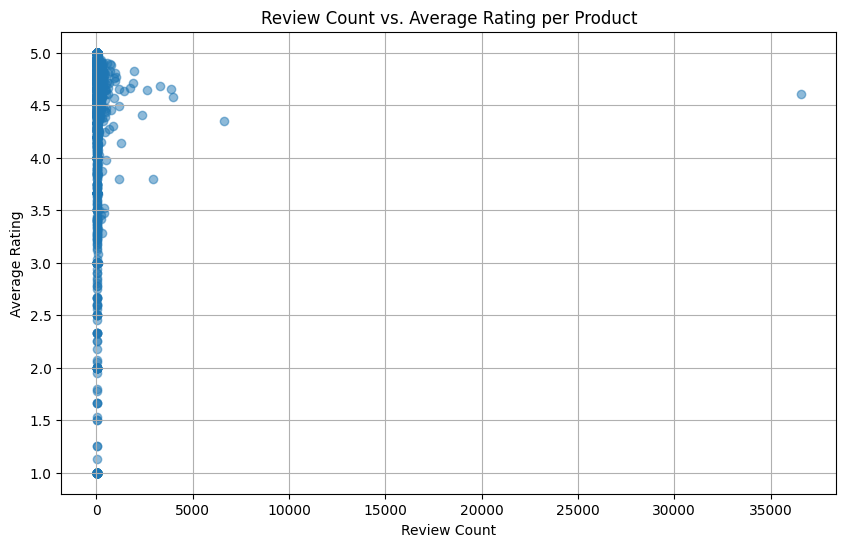

In [0]:
import matplotlib.pyplot as plt

# Convert product_stats to Pandas for plotting
product_stats_pd = product_stats.select("review_count", "avg_rating").toPandas()

plt.figure(figsize=(10, 6))
plt.scatter(product_stats_pd["review_count"], product_stats_pd["avg_rating"], alpha=0.5)
plt.xlabel("Review Count")
plt.ylabel("Average Rating")
plt.title("Review Count vs. Average Rating per Product")
plt.grid(True)
plt.show()

3️⃣ Product-Level EDA (VERY IMPORTANT)

Columns used

asin, parent_asin, rating

What Did I analyze

Review count per product

Average rating per product

Products with:

High review count + low rating

Low review count + extreme ratings

In [0]:
from pyspark.sql.functions import count, avg, col

# Review count and average rating per product
product_stats = analysis_df.groupBy("asin", "parent_asin").agg(
    count("*").alias("review_count"),
    avg("rating").alias("avg_rating")
)
display(product_stats.orderBy(col("review_count").desc()))

# Products with high review count (top 10%) and low average rating (<=2.5)
review_count_threshold = product_stats.approxQuantile("review_count", [0.9], 0.01)[0]
high_count_low_rating = product_stats.filter(
    (col("review_count") >= review_count_threshold) & (col("avg_rating") <= 2.5)
)
display(high_count_low_rating)

# Products with low review count (bottom 10%) and extreme average ratings (<=2 or >=4.5)
low_count_threshold = product_stats.approxQuantile("review_count", [0.1], 0.01)[0]
low_count_extreme_rating = product_stats.filter(
    (col("review_count") <= low_count_threshold) & ((col("avg_rating") <= 2) | (col("avg_rating") >= 4.5))
)
display(low_count_extreme_rating)

asin,parent_asin,review_count,avg_rating
B00IX1I3G6,B00IX1I3G6,36583,4.60358636525162
B086KKT3RX,B086KKT3RX,6635,4.348304446119066
B01K8RMDO0,B077N4CNVJ,3988,4.5779839518555665
B0719C5P56,B0719C5P56,3885,4.655341055341055
B01K8RJDEI,B00ADR2LV6,3312,4.682367149758454
B01MSBQB1P,B01MSBQB1P,2942,3.79537729435758
B01C9MW8Z6,B00JFBLZ90,2622,4.646453089244852
B06WVJBLBQ,B071X4ZX3X,2367,4.408111533586819
B072P5VV4D,B00ADR2LV6,1963,4.821192052980132
B07FK7L976,B00ADR2LV6,1902,4.709779179810726


asin,parent_asin,review_count,avg_rating


asin,parent_asin,review_count,avg_rating
B01DCN55M4,B005S28ZES,1,5.0
B009WD1I7A,BT00CTOUNS,1,5.0
B00BXLTRNG,B00BXLTR6S,1,5.0
B014S24C4K,B018F4M89S,1,5.0
B0091JKWUE,B00ADR2LV6,1,5.0
B08DJWJ9R5,B08DJWJ9R5,1,1.0
B0091JKXNU,B00ADR2LV6,1,5.0
B076J1X53Z,B076J1X53Z,1,1.0
B07WT7CLYB,B07WT7RCGL,1,5.0
B00PMFBOD0,B00PMFBOD0,1,5.0


4️⃣ Trust & Credibility Analysis


Columns used

verified_purchase, helpful_vote, rating

What to analyze

- % verified vs non-verified reviews

- Average rating: verified vs non-verified

- Helpful votes distribution

- Helpful votes vs low ratings

In [0]:
from pyspark.sql.functions import col, avg, count, sum as spark_sum

# % verified vs non-verified reviews
verified_counts = analysis_df.groupBy("verified_purchase").agg(count("*").alias("count"))
total_reviews = analysis_df.count()
verified_counts = verified_counts.withColumn("percentage", (col("count") / total_reviews) * 100)
display(verified_counts)

# Average rating: verified vs non-verified
avg_rating_verified = analysis_df.groupBy("verified_purchase").agg(avg("rating").alias("avg_rating"))
display(avg_rating_verified)

# Helpful votes distribution
helpful_vote_dist = analysis_df.groupBy("helpful_vote").agg(count("*").alias("count")).orderBy(col("helpful_vote").desc())
display(helpful_vote_dist)

# Helpful votes vs low ratings (1–2)
helpful_vs_low_rating = analysis_df.filter(col("rating").isin([1, 2])).groupBy("helpful_vote").agg(count("*").alias("low_rating_count")).orderBy(col("helpful_vote").desc())
display(helpful_vs_low_rating)

verified_purchase,count,percentage
true,136390,94.17442880125944
false,8437,5.825571198740566


verified_purchase,avg_rating
true,4.614935112544908
false,3.588479317292877


helpful_vote,count
4536,1
2364,1
1355,1
1114,1
1009,1
862,1
835,1
693,1
674,1
673,1


helpful_vote,low_rating_count
4536,1
1355,1
1114,1
1009,1
835,1
693,1
674,1
673,1
578,1
507,1


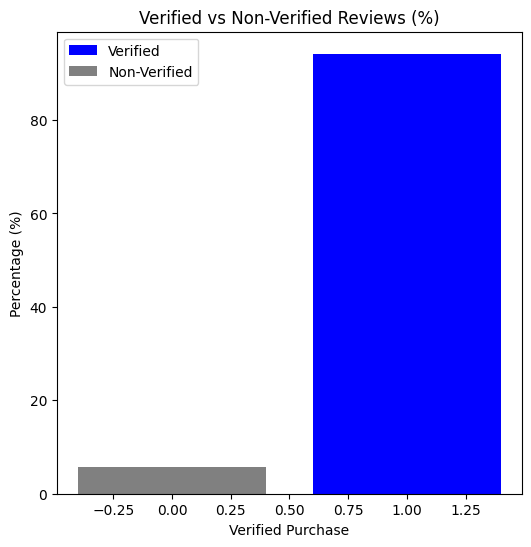

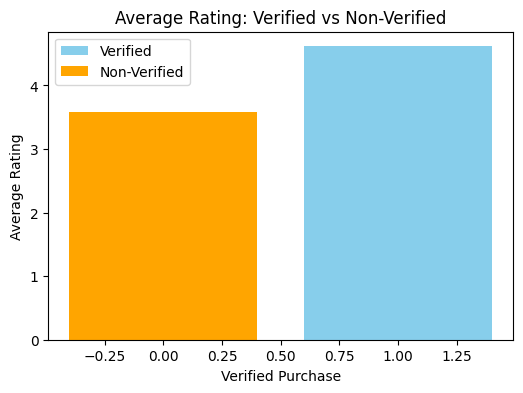

In [0]:
import matplotlib.pyplot as plt

# Verified vs Non-verified review percentages
verified_pd = verified_counts.toPandas()
plt.figure(figsize=(6, 6))
plt.bar(verified_pd["verified_purchase"], verified_pd["percentage"], color=['blue', 'gray'], label=['Verified', 'Non-Verified'])
plt.xlabel("Verified Purchase")
plt.ylabel("Percentage (%)")
plt.title("Verified vs Non-Verified Reviews (%)")
plt.legend()
plt.show()

# Average rating: verified vs non-verified
avg_rating_verified_pd = avg_rating_verified.toPandas()
plt.figure(figsize=(6, 4))
plt.bar(avg_rating_verified_pd["verified_purchase"], avg_rating_verified_pd["avg_rating"], color=['skyblue', 'orange'], label=['Verified', 'Non-Verified'])
plt.xlabel("Verified Purchase")
plt.ylabel("Average Rating")
plt.title("Average Rating: Verified vs Non-Verified")
plt.legend()
plt.show()
